In [1]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import plot_utils as pu

In [2]:
# configure the backend for matplotlib
# this one should allow zoom:
%matplotlib widget
# to make that work you need: "pip install ipympl" and run "jupyter nbextension enable --py widgetsnbextension"

# this will work without the above dependencies but won't allow zoom
# %matplotlib inline

# this option may work whenever they fix bugs in mpld3
# import mpld3
# mpld3.enable_notebook()

Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Running model: 2D from bottom (upper bounded)
   Negated 2 constraints on 2D from bottom (upper bounded)
   Relaxed 2 variables on 2D from bottom (upper bounded)
   Gap to target: 0.11111111111111116 : [1.         2.11111111] to [1. 2.]
   Gap to target: 0.08504076274779769 : [0.92143258 2.03254369] to [1. 2.]
   Final score of relaxed: 1.9999999999999996


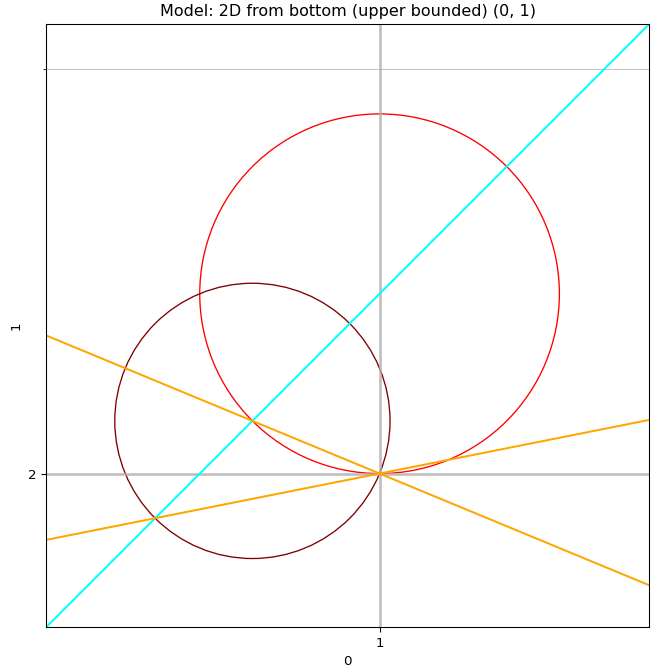

Running model: 2D from bottom (upper bounded)
   Negated 2 constraints on 2D from bottom (upper bounded)
   Relaxed 2 variables on 2D from bottom (upper bounded)
   Gap to target: 0.050000000000000044 : [1.05 2.  ] to [1. 2.]
   Gap to target: 0.09999999999999987 : [1.1 2. ] to [1. 2.]
   Gap to target: 0.20000000000000062 : [1.2 2. ] to [1. 2.]
   Gap to target: 0.40000000000000147 : [1.4 2. ] to [1. 2.]
   Gap to target: 0.45565671213238396 : [1.45461625 1.96922498] to [1. 2.]
   Gap to target: 0.10447170426690519 : [1.03524812 1.90165415] to [1. 2.]
   Gap to target: 0.20080242920392646 : [1.11736067 1.83706416] to [1. 2.]


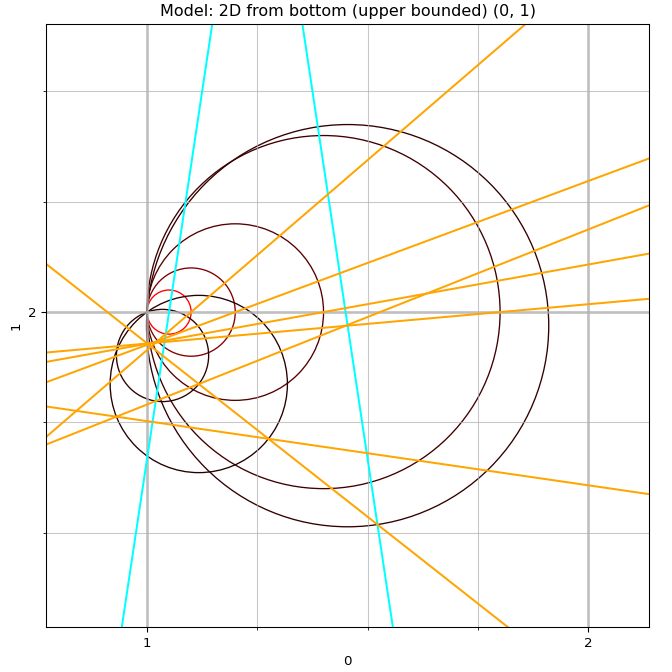

In [5]:
# A function to create cuts given a target point
def add_balas_ball_cut(relaxed: gp.Model, target, integer_vars, integer_idx, plotter, bounds_tightening=False):
    # for each column in the tableau
    # construct a sparse vector for it
    # get the length of that vector via norm1 (plus 1 if we're an int column)
    # add our cut: sum_j(x_j/a_j)
    
    norm = 2
    current = integer_vars.X
    radius = np.linalg.norm(current - target, norm)
    if radius <= relaxed.params.FeasibilityTol:
        return False  # TODO: tolerance should apply to each component individually?
    
    print("   Gap to target:", radius, ":", current[:7], "to", target[:7])
    if plotter is not None:
        plotter.add_ball(current, radius)

    variables = relaxed.getVars()  # TODO: pass this in as it's expensive?
    constraints = relaxed.getConstrs()  # wish we didn't have to use this one
    
    basis = gu.read_basis(relaxed)
    tableau, col_to_var, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=1)
    negated_vars = [basis[nr] for nr in negated_rows]
    
    # drop the rows of non-integer variables:
    to_drop = [i for i, base in enumerate(basis) if base not in integer_idx]
    tableau = np.delete(tableau, to_drop, axis=0)
    basis = np.delete(basis, to_drop)

    # Conforti has negative vectors with 1 at row=col, with the rest negated.
    # However, empirically, it seems that the opposite is what we really want (gurobi-specific or standardization issue)
    int_cols = [i for i, c in enumerate(col_to_var) if c in integer_idx]
    tableau[-1, int_cols] = -1  # use our extra row to store the col==row -> 1
    lengths = np.linalg.norm(tableau, norm, axis=0)
    lengths /= radius

    if bounds_tightening:  # assuming this is only true on a feasible target
        for i, base in enumerate(basis):
            all_same_sign = np.all(tableau[i, :] >= 0) or np.all(tableau[i, :] <= 0)  # TODO: find a more efficient call for this
            if all_same_sign and target[integer_idx[base]] > current[integer_idx[base]]:
                new_con = relaxed.addConstr(variables[base] >= target[integer_idx[base]])
                print("Tightened!")
                if plotter is not None:
                    relaxed.update()
                    plotter.add_constraint(new_con, color='green')
            elif all_same_sign and target[integer_idx[base]] < current[integer_idx[base]]:
                new_con = relaxed.addConstr(-variables[base] >= -target[integer_idx[base]])
                print("Tightened!")
                if plotter is not None:
                    relaxed.update()
                    plotter.add_constraint(new_con, color='green')
    
    def find_variable(index):
        if index < len(variables):
            # handle inverted variables (SCIP and Gurobi both have this silliness)
            if variables[index].VBasis == -2:
                return variables[index].X - variables[index]
            assert variables[index].VBasis == -1  # not handling -3 yet
            return variables[index]
        # if only gurobi gave us access to their slack variables...
        # instead, we have to solve for it:
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        # if constraint.Sense != '>':
        #     assert constraint.Sense == '='
        #     return 0.0  # ignore equality constraints with slacks (as gurobi generates a slack for every constraint)
        lhs, rhs = relaxed.getRow(constraint), constraint.RHS
        # if cons_idx in negated_vars:
        #     return rhs - lhs
        return lhs - rhs
    
    summed_terms = gp.quicksum(lengths[i] * find_variable(j) for i, j in enumerate(col_to_var))
    new_con = relaxed.addConstr(summed_terms >= 1)

    # def find_variable_value(index):
    #     if index < len(variables):
    #         return variables[index].X
    #     cons_idx = index - len(variables)
    #     constraint = constraints[cons_idx]
    #     try:
    #         return constraint.Slack
    #     except:
    #         return 0.0

    # full_current = sum(lengths[i] * find_variable_value(j) for i, j in enumerate(col_to_var))
    # print("   CLOSED:", (full_current - 1) / np.linalg.norm(lengths, norm))
    
    # what does it mean to take a relaxed point in full space and compare only its want-to-be-integer components to another?
    if plotter is not None:
        relaxed.update()
        plotter.add_constraint(new_con)
    return True

# a function to run cuts against the nearest integer:
def run_cuts_to_nearest_int(instances, cut_function, loops=7, graph_2D_3D=True):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        model.params.Method = 1
        gu.standardize_lt_to_gt(model)
        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        plotter = pu.create(model) if graph_2D_3D else None
        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break
            nearest = gu.nearest_integer(int_vars)
            if not cut_function(model, nearest, int_vars, int_idx, plotter, False):
                print("   Final score of relaxed:", model.getObjective().getValue())
                break
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples:
run_cuts_to_nearest_int(list(el.get_instances().values())[4:], add_balas_ball_cut)

In [ ]:
def run_cuts_to_relaxed_sol(instances, cut_function, loops=8):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        gu.standardize_lt_to_gt(model)
        plotter = pu.create(model)

        exact_model = model.copy()
        exact_model.update()
        exact_vars = gp.MVar.fromlist([v for v in exact_model.getVars() if v.VType != 'C'])
        z = exact_model.addMVar(exact_vars.shape, lb=-gp.GRB.INFINITY)
        exact_model.setObjective(z.sum(), gp.GRB.MINIMIZE)

        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break

            relaxed_x = int_vars.X
            ca = exact_model.addConstr(z >= exact_vars - relaxed_x)
            cb = exact_model.addConstr(z >= relaxed_x - exact_vars)
            exact_model.optimize()
            assert exact_model.Status == gp.GRB.OPTIMAL

            if not cut_function(model, exact_vars.X, int_vars, int_idx, plotter, True):
                print("   Final score of relaxed:", model.getObjective().getValue())
                break

            exact_model.remove(ca)
            exact_model.remove(cb)
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples:
run_cuts_to_relaxed_sol(list(el.get_instances().values())[3:], add_balas_ball_cut)

In [ ]:
miplib_instances = ml.get_instances()
miplib_subset = [miplib_instances['air05'], miplib_instances['markshare2']]  # mas76
run_cuts_to_relaxed_sol(miplib_subset, add_balas_ball_cut)

In [ ]:
import jsplib_loader as jl
jsplib_instances = jl.get_instances()
jsplib_subset = [jsplib_instances['abz5']]
run_cuts_to_relaxed_sol(jsplib_subset, add_balas_ball_cut)
# jsplib_subset[0].as_gurobi_model().optimize()